<a href="https://colab.research.google.com/github/aashutoshraj521/Computer-Vision/blob/main/Reason_for_Scharr_Operator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

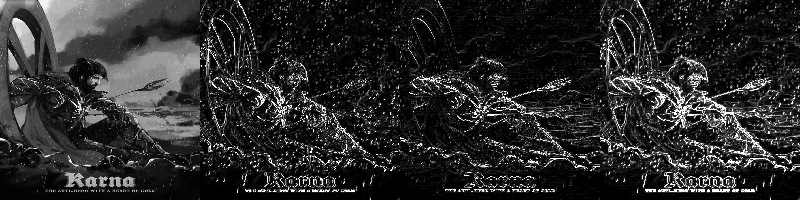

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/karna.jpg", 0)

# Sobel X
sobel_x = cv2.Sobel(image,cv2.CV_64F,1,0,ksize=3)

# Sobel Y
sobel_y = cv2.Sobel(image,cv2.CV_64F,0,1,ksize=3)

# Gradient magnitude
sobel = np.sqrt(sobel_x**2 +sobel_y**2)

# Display
from google.colab.patches import cv2_imshow

# 1. Resize each image so they fit comfortably side-by-side
small_size = (200, 200) # Width, Height for each individual image
img_resized = cv2.resize(image, small_size)

# Normalizing the 64F float images to 8-bit unsigned integers so they display correctly with hstack
sobel_x_resized = cv2.convertScaleAbs(cv2.resize(sobel_x, small_size))
sobel_y_resized = cv2.convertScaleAbs(cv2.resize(sobel_y, small_size))
sobel_resized = cv2.convertScaleAbs(cv2.resize(sobel, small_size))

# 2. Stack them horizontally into a single image row
side_by_side = np.hstack((img_resized, sobel_x_resized, sobel_y_resized, sobel_resized))

# 3. Display the single combined row
cv2_imshow(side_by_side)

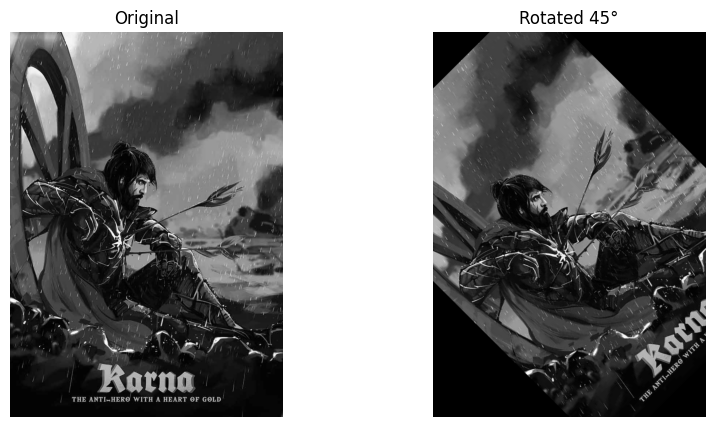

In [15]:
# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get image dimensions
(h, w) = image_rgb.shape[:2]

# Center of rotation
center = (w // 2, h // 2)

# Rotation matrix
M = cv2.getRotationMatrix2D(center, 45, 1.0)

# Rotate image
rotated = cv2.warpAffine(image_rgb, M, (w, h))

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rotated)
plt.title("Rotated 45°")
plt.axis("off")

plt.show()

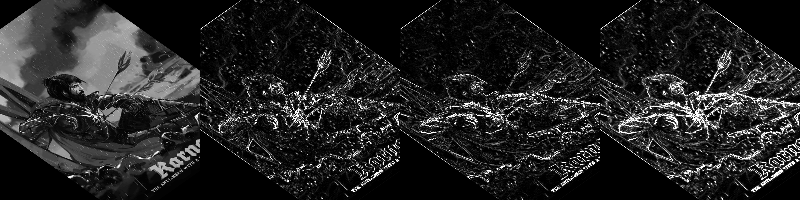

In [16]:
import numpy as np
# Sobel X
sobel_x = cv2.Sobel(rotated,cv2.CV_64F,1,0,ksize=3)

# Sobel Y
sobel_y = cv2.Sobel(rotated,cv2.CV_64F,0,1,ksize=3)

# Gradient magnitude
sobel = np.sqrt(sobel_x**2 +sobel_y**2)

# Display
from google.colab.patches import cv2_imshow

# 1. Resize each image so they fit comfortably side-by-side
small_size = (200, 200) # Width, Height for each individual image
img_resized = cv2.resize(rotated, small_size)

# Normalizing the 64F float images to 8-bit unsigned integers so they display correctly with hstack
sobel_x_resized = cv2.convertScaleAbs(cv2.resize(sobel_x, small_size))
sobel_y_resized = cv2.convertScaleAbs(cv2.resize(sobel_y, small_size))
sobel_resized = cv2.convertScaleAbs(cv2.resize(sobel, small_size))

# 2. Stack them horizontally into a single image row
side_by_side = np.hstack((img_resized, sobel_x_resized, sobel_y_resized, sobel_resized))

# 3. Display the single combined row
cv2_imshow(side_by_side)

According to Researchers, If an edge rotates slightly, Sobel may respond differently even though the edge strength is identical.

Researchers wanted a more accurate gradient detector.

That led to the Scharr operator.